In [12]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from helpers.generic_cavity_operators import CavityQEDSystem
from helpers.input_shapes import real_input_shape
from helpers.compute_simulation import simulate, compute_output_field
from helpers.plotting import plot_qswitch_dynamics
from IPython.display import display, Markdown, Latex
from sympy import Matrix
from IPython.display import display, Math

In [2]:
# -----------------------
# ------ Constants ------
# -----------------------

# Clebsch-Gorden coefficient D2 line (F2 -> F'3)
Mu0 = -np.sqrt(1 / 6)  # pi (mf2 -> mf2)
Mu1 = -np.sqrt(3 / 10)  # pi (mf0 -> mf0)

G0_kc = 2 * np.pi * 0.0438  # coupling strength (F2mf2 -> F'3mf2)
G_pi_KC = G0_kc * (Mu1 / Mu0)  # coupling strength (F2mf0 -> F'3mf0)

Kappa = 2 * np.pi * 0.063  # cavity dissipation rate
Kappa_oc = 2 * np.pi * 0.054
Gamma_5P32_5S = 2 * np.pi * 0.006065 / 2  # atom dissipation rate

Mu_rf = 1
Mu_fc = 0.9

Atom_dimensions = 5  # |F=1,m_f=0>,|F=2,m_f=0>,|F=2,m_f=-1>,|F=2,m_f=+1>,|F'=3,m_f=0>
Photon_dimensions = [2,2]  # only π-pol. light is able to enter our cavity

tlist = np.linspace(0, 5000, 10000, dtype=np.float32)
args = {"t0": 1000.0, "tau": 70.0, "tau_start": 91.0}

In [3]:
# -----------------------
# ---- System Params-----
# -----------------------

qced = CavityQEDSystem(
    photon_dimensions=Photon_dimensions, atom_dimensions=Atom_dimensions
)

obs = [
    qced.projection_operators[(0, 0)],  # |F=1,m_f=0><F=1,m_f=0|
    qced.projection_operators[(1, 1)],  # |F=2,m_f=0><F=2,m_f=0|
    qced.projection_operators[(4, 4)],  # |F'=3,m_f=0><F'=3,m_f=0|
    qced.annihilation_operators["a0"].dag()
    * qced.annihilation_operators["a0"],  # a.dag*a=n
    qced.annihilation_operators["a0"],
]

c_obs = [
    np.sqrt(2 * Kappa) * qced.annihilation_operators["a0"],
    np.sqrt(2 * Gamma_5P32_5S * 1 / 10)
    * qced.projection_operators[(2, 4)],  # |F'=3,m_f=0> -> |F=2,m_f=-1>
    np.sqrt(2 * Gamma_5P32_5S * 1 / 10)
    * qced.projection_operators[(3, 4)],  # |F'=3,m_f=0> -> |F=2,m_f=+1>
]


In [4]:
input_states = {
    "0": qced.atomic_states[0],
    "1": qced.atomic_states[1],
    "+": (qced.atomic_states[0] + qced.atomic_states[1]).unit(),
    "-": (qced.atomic_states[0] - qced.atomic_states[1]).unit(),
}

In [26]:
def compute_phase_shift(a_in: np.ndarray, a_out: np.ndarray) -> float:
    # Compute average complex phase shift
    ratio = a_out / a_in
    return np.angle(np.mean(ratio[np.abs(a_in) > 1e-3]))


for label, psi in input_states.items():
    result = simulate(
        psi,
        qced.projection_operators,
        qced.annihilation_operators,
        Photon_dimensions,
        G_pi_KC,
        Kappa_oc,
        real_input_shape,
        tlist,
        c_obs,
        obs,
        args,
    )
    a_out = compute_output_field(result, real_input_shape, args, tlist, Kappa_oc)
    a_in = np.array([real_input_shape(t, args) for t in tlist])
    phase_shift = compute_phase_shift(a_in, a_out)

    print(f"{label} -> phase shift: {phase_shift} rad")

    photon_state = result.states[-1].full()

    # Convert to SymPy Matrix for LaTeX rendering
    sympy_matrix = Matrix(photon_state)
    latex_code = r"\text{Final Photon State for " + label + r"}: " + sympy_matrix._repr_latex_()

    # Display LaTeX matrix
    display(Math(latex_code))

0 -> phase shift: 3.141592653589793 rad


/tmp/ipykernel_22178/605729830.py:3: RuntimeWarning: divide by zero encountered in divide
  ratio = a_out / a_in
/tmp/ipykernel_22178/605729830.py:3: RuntimeWarning: invalid value encountered in divide
  ratio = a_out / a_in


<IPython.core.display.Math object>

1 -> phase shift: 0.0 rad


<IPython.core.display.Math object>

+ -> phase shift: 0.0 rad


<IPython.core.display.Math object>

- -> phase shift: 0.0 rad


<IPython.core.display.Math object>

In [22]:
print(final_state_0.ptrace(0).purity())
projected_final = P_vacuum * final_state_0 * P_vacuum.dag()
projected_final_atom = projected_final.ptrace(0)
projected_final_atom

0.6469126479061478


Quantum object: dims=[[5], [5]], shape=(5, 5), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 5.00000000e-01  2.76794457e-01  0.00000000e+00  0.00000000e+00
  -9.69983400e-26]
 [ 2.76794457e-01  4.93621267e-01  0.00000000e+00  0.00000000e+00
  -1.72981942e-25]
 [ 0.00000000e+00  0.00000000e+00  3.18937451e-03  0.00000000e+00
   0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  3.18937451e-03
   0.00000000e+00]
 [-9.69983400e-26 -1.72981942e-25  0.00000000e+00  0.00000000e+00
  -2.14931693e-08]]

In [24]:
final_state_0.ptrace(0)

Quantum object: dims=[[5], [5]], shape=(5, 5), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 5.00000000e-01  2.76794457e-01  0.00000000e+00  0.00000000e+00
  -9.69983400e-26]
 [ 2.76794457e-01  4.93621272e-01  0.00000000e+00  0.00000000e+00
  -1.72981940e-25]
 [ 0.00000000e+00  0.00000000e+00  3.18937451e-03  0.00000000e+00
   0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  3.18937451e-03
   0.00000000e+00]
 [-9.69983400e-26 -1.72981940e-25  0.00000000e+00  0.00000000e+00
  -2.14931693e-08]]

In [11]:
final_state_1.ptrace(0)

Quantum object: dims=[[5], [5]], shape=(5, 5), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 5.00000000e-01 -2.76794457e-01  0.00000000e+00  0.00000000e+00
   9.69983400e-26]
 [-2.76794457e-01  4.93621272e-01  0.00000000e+00  0.00000000e+00
  -1.72981940e-25]
 [ 0.00000000e+00  0.00000000e+00  3.18937451e-03  0.00000000e+00
   0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  3.18937451e-03
   0.00000000e+00]
 [ 9.69983400e-26 -1.72981940e-25  0.00000000e+00  0.00000000e+00
  -2.14931693e-08]]

In [26]:
a_out_0 = compute_output_field(result_0, real_input_shape, args, tlist, Kappa_oc)
a_out_1 = compute_output_field(result_1, real_input_shape, args, tlist, Kappa_oc)



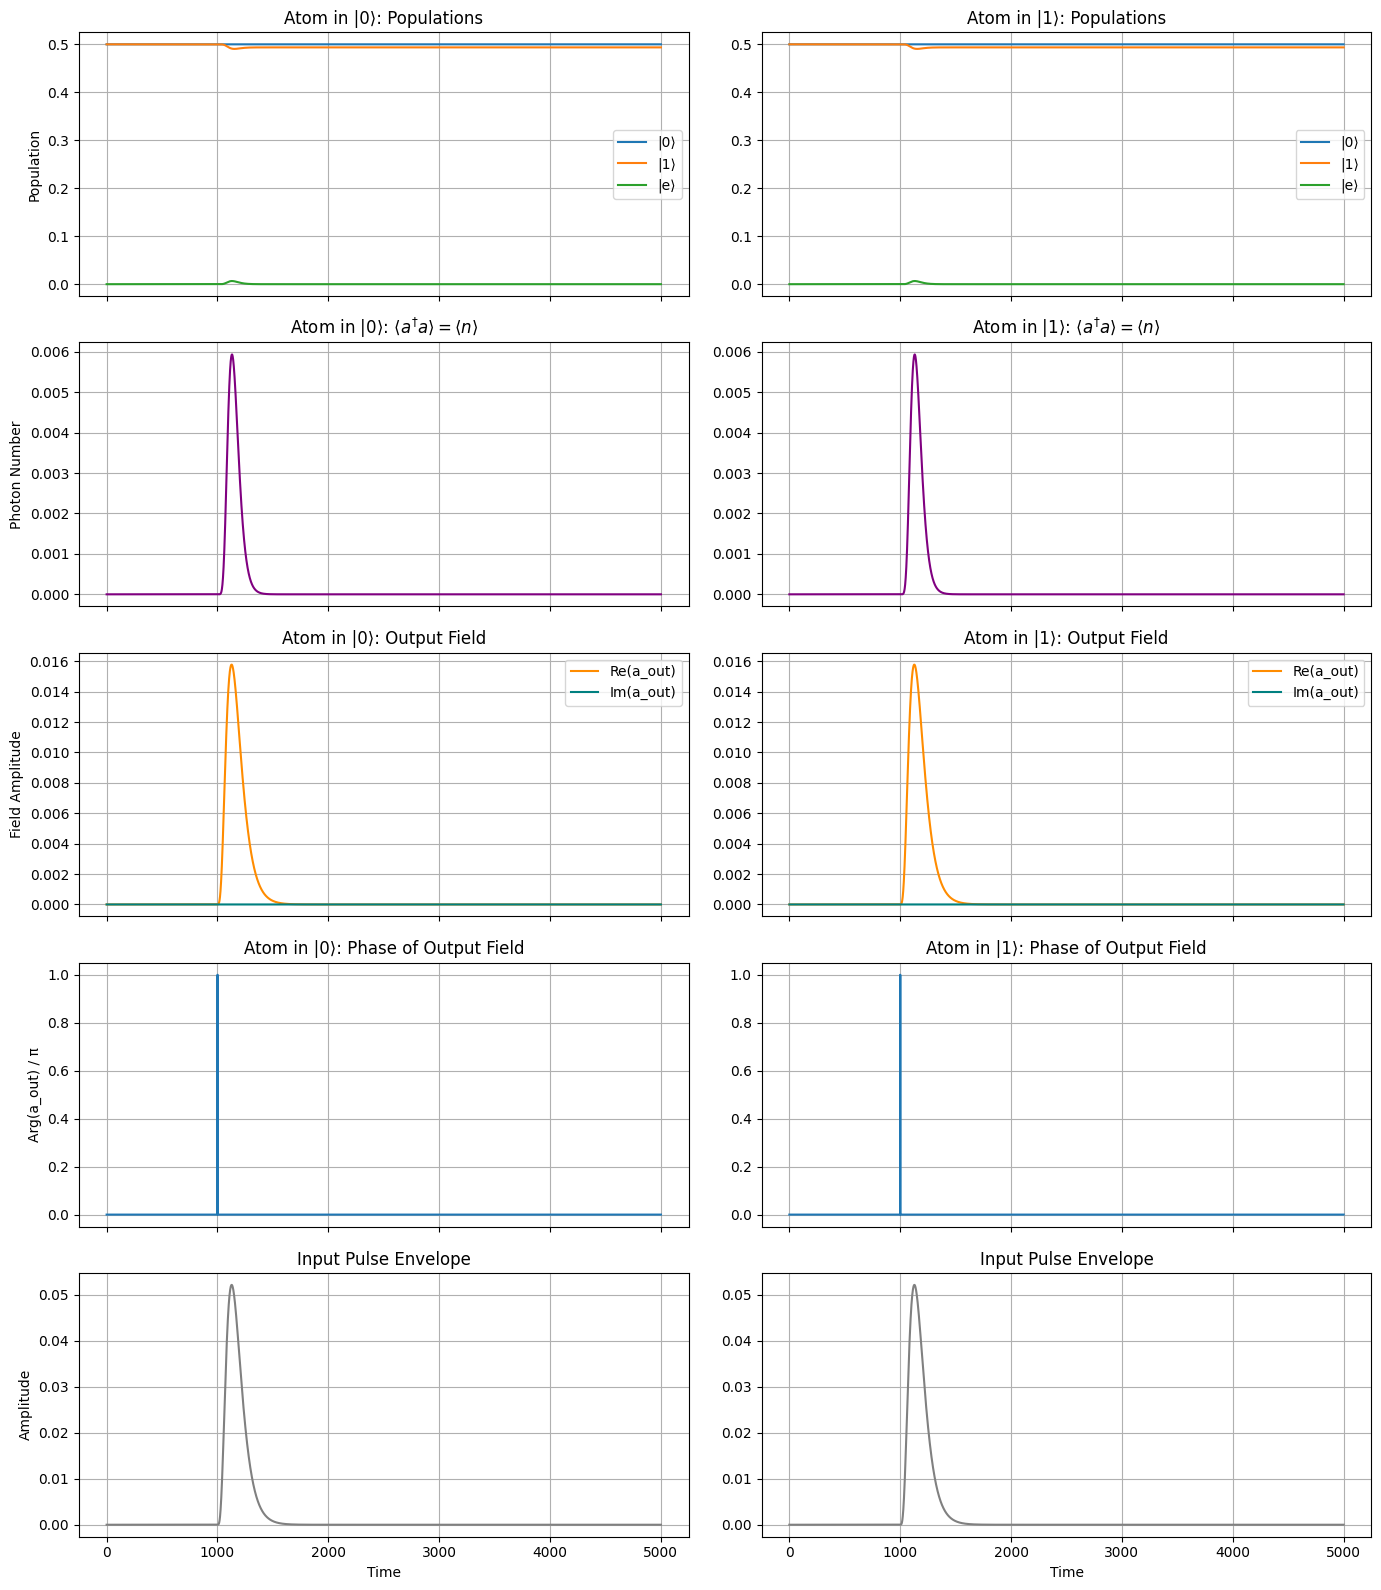

In [27]:
plot_qswitch_dynamics(
    tlist, result_0, result_1, a_out_0, a_out_1, real_input_shape, args
)

In [ ]:
}}}}